Weights should not be very small? Why? If it is very small it causes vanishing gradient problem

Vanishing gradient and Exploding gradient problem mainly occurs because of wrong weight initialization and activation function

**Initialization :**

Initialization is a technique used in artificial neural networks to set the initial values of the weights before starting the training process. The goal of this technique is to improve the training process by assigning random values to the weights in a way that makes the training more stable and less prone to computational issues


---





In [25]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

In [26]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
np.random.seed(42)

[name for name in dir(keras.initializers) if not name.startswith('_')] # Displaying Available Initializers in Keras
# The code imports NumPy and TensorFlow (including Keras) and then retrieves a list of all available initialization functions in Keras,
# excluding private names (those starting with _)

['Constant',
 'GlorotNormal',
 'GlorotUniform',
 'HeNormal',
 'HeUniform',
 'Identity',
 'IdentityInitializer',
 'Initializer',
 'LecunNormal',
 'LecunUniform',
 'Ones',
 'Orthogonal',
 'OrthogonalInitializer',
 'RandomNormal',
 'RandomUniform',
 'STFT',
 'STFTInitializer',
 'TruncatedNormal',
 'VarianceScaling',
 'Zeros',
 'constant',
 'deserialize',
 'get',
 'glorot_normal',
 'glorot_uniform',
 'he_normal',
 'he_uniform',
 'identity',
 'lecun_normal',
 'lecun_uniform',
 'ones',
 'orthogonal',
 'random_normal',
 'random_uniform',
 'serialize',
 'stft',
 'truncated_normal',
 'variance_scaling',
 'zeros']

✅ These Initializers help improve the stability and learning of the model when starting training

=> Specifies how initial values ​​are assigned to weights in the model




---


creating a Dense layer with ReLU activation and He Normal weight initialization

**Note :**

ReLU is better than sigmoid because it does not saturate for positive values and is fast.


Although Relu is a non-saturating function but it has a big problem called Dying ReLUs   ⎧ᴿᴵᴾ⎫ ❀-😔  
where a neuron dies when its input is negative for all training instances.

**The Impact of dying Relus:**

Reduced Capacity

Wasted Resources

Slower Training


In [27]:
keras.layers.Dense(10,activation='relu',kernel_initializer='he_normal')
# This line creates a Dense layer with 10 neurons
# The activation function is "ReLU" (which determines the output of each neuron based on its input)
# The weights are initialized using the "He Normal" method, which helps in better weight initialization for deep networks


<Dense name=dense_107, built=False>

When a Dense layer is created in Keras, it is initially in an unbuilt state (built=False) until data is passed to it (such as training data or a model.build() call), at which point the layer is built, weights are set, and initialized correctly

---

**Nonsaturating Activation Functions**


**Leaky ReLU**

How does Leaky ReLU address the Dying ReLUs problem? 🧚‍♂️

In Leaky ReLU, a small gradient is allowed to flow when the inputs are negative, instead of setting them to zero as in ReLU.

This gradient is controlled by the α (alpha) parameter, which is typically set between 0.01 and 0.3.

In [28]:
def leaky_relu(z,alpha=0.01):
  return np.maximum(alpha*z,z)
# The difference is adding alpha parameter to solve the dying ReLU problem

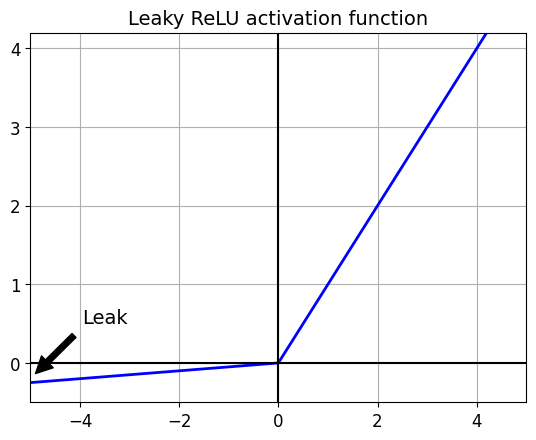

In [29]:
z = np.linspace(-5, 5, 200)
plt.plot(z, leaky_relu(z, 0.05), "b-", linewidth=2)
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([0, 0], [-0.5, 4.2], 'k-')
plt.grid(True)
props = dict(facecolor='black', shrink=0.1)
plt.annotate('Leak', xytext=(-3.5, 0.5), xy=(-5, -0.2), arrowprops=props, fontsize=14, ha="center")
plt.title("Leaky ReLU activation function", fontsize=14)
plt.axis([-5, 5, -0.5, 4.2])
plt.show()


In [30]:
[m for m in dir(keras.activations) if not m.startswith("_")] # Activation functions in Keras

['celu',
 'deserialize',
 'elu',
 'exponential',
 'gelu',
 'get',
 'glu',
 'hard_shrink',
 'hard_sigmoid',
 'hard_silu',
 'hard_swish',
 'hard_tanh',
 'leaky_relu',
 'linear',
 'log_sigmoid',
 'log_softmax',
 'mish',
 'relu',
 'relu6',
 'selu',
 'serialize',
 'sigmoid',
 'silu',
 'soft_shrink',
 'softmax',
 'softplus',
 'softsign',
 'sparse_plus',
 'sparsemax',
 'squareplus',
 'swish',
 'tanh',
 'tanh_shrink',
 'threshold']

Activation functions control how each neuron responds to the input data

Activation functions affect how signals are passed through the neural network

In [31]:
[m for m in dir(keras.layers)if 'relu'in m.lower()]

['LeakyReLU', 'PReLU', 'ReLU', 'ThresholdedReLU']



---



**Leaky ReLU**

Train a neural network on Fashion MNIST using **Leaky ReLU**

 loads, normalizes, and splits the Fashion MNIST dataset to prepare it for training a neural network using Keras

In [32]:
# Loads the Fashion MNIST dataset, which consists of grayscale clothing images (28 × 28 pixels) across 10 classes
(X_train_full,y_train_full),(X_test,y_test) = keras.datasets.fashion_mnist.load_data()
# The dataset is divided into :
# X_train_full & y_train_full: Full training data
# X_test & y_test: Test data
# Normalization (Scaling Pixel Values): Normalizes the pixel values from a range of 0-255 to 0-1 to speed up training and improve model performance
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0
# Splitting Training Data into Training and Validation Sets:
# first 5,000 images are used as a validation set
# The remaining images are used for actual training
y_valid,y_train = y_train_full[:5000],y_train_full[5000:]
X_valid,X_train = X_train_full[:5000],X_train_full[5000:]



---



In [33]:
# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28,28]), # Flatten converts the 2D (28×28) image into a 1D vector (784 elements) => Dense layers require 1D input
    # First Hidden Layer
    keras.layers.Dense(300,kernel_initializer='he_normal'),
    keras.layers.LeakyReLU(),
    # Dense(300): Fully connected layer with 300 neurons
    # kernel_initializer='he_normal': Uses He initialization, suitable for ReLU-based layers

    # Second Hidden Layer
    keras.layers.Dense(100,kernel_initializer='he_normal'),
    keras.layers.LeakyReLU(),
    # Fully connected layer with 100 neurons
    # Uses He initialization and LeakyReLU activation

    # Output Layer
    keras.layers.Dense(10,activation='softmax')
    # 10 neurons (one for each Fashion MNIST class)
    # Uses Softmax activation, which converts logits into probabilities between 0 & 1, ensuring the sum of outputs = 1

])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


The code defines an artificial neural network model using Keras for Fashion MNIST classification

The model consists of three dense layers with LeakyReLU and Softmax activation

**Types of keras Models**
1. The Sequential Model : simple , Only for single-input , single-output , sequential layer stacks

2. The functional API : like playing with lego bricks 🧱 , Multi-input, Multi-output


---

In the code I use the Sequential Model


---



In [34]:
# Compiling the Model (compile)
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=['accuracy'])
# Loss is computed using Sparse Categorical Crossentropy
# Weights are updated using SGD with a 0.001 learning rate

In [35]:
# Training the Model (fit)
history = model.fit(X_train,y_train,epochs=10,
                    validation_data=(X_valid,y_valid))
# Model trains for 10 epochs
# After each epoch, accuracy is evaluated on the validation set

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.4862 - loss: 1.6552 - val_accuracy: 0.7102 - val_loss: 0.8721
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7216 - loss: 0.8290 - val_accuracy: 0.7712 - val_loss: 0.7008
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.7729 - loss: 0.6920 - val_accuracy: 0.7986 - val_loss: 0.6270
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7946 - loss: 0.6264 - val_accuracy: 0.8148 - val_loss: 0.5827
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8069 - loss: 0.5854 - val_accuracy: 0.8242 - val_loss: 0.5525
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8152 - loss: 0.5567 - val_accuracy: 0.8300 - val_loss: 0.5302
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8216 - loss: 0.5352 - val_accuracy: 0.8348 - val_loss: 0.5130
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.8270 - loss: 0

accuracy: 0.8321 (83.21%)

val_accuracy: 0.8416 (84.16%) : The model accuracy on the validation set

The average loss on the training data was 0.4880

The loss on verification data was 0.4772

=> Being less than the loss on the training data (0.4880) indicates that the model did not suffer from **overfitting**



---



**ELU**

In [36]:
def elu(z, alpha=1):
    return np.where(z < 0, alpha * (np.exp(z) - 1), z)

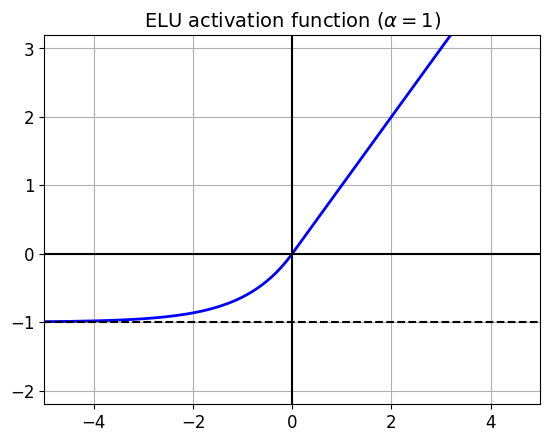

In [37]:
plt.plot(z, elu(z), "b-", linewidth=2)
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [-1, -1], 'k--')
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.title(r"ELU activation function ($\alpha=1$)", fontsize=14)
plt.axis([-5, 5, -2.2, 3.2])
plt.show()

 plotting the ELU activation function over the range from x = -5 to 5

 If the z value is negative (i.e., z < 0), the ELU function calculates:

ELU(z)=α×(exp(z)−1)

If the z value is positive or zero (i.e., z ≥ 0), the ELU function returns the value z itself

alpha is a controllable parameter (the default value is 1)

**Note** that ELU is Non-Linear exponential curve , which helps in improving performance by handling negative inputs more effectively than ReLU.



---

the following code :

The dense layer uses 10 neurons and applies an ELU activation function, which helps the network learn complex relationships between data (through nonlinear activation)







In [38]:
keras.layers.Dense(10, activation="elu")

<Dense name=dense_111, built=False>



---

SELU

Scaled Exponential Linear Unit (SELU) performs exceptionally well, especially with dense layers and CNNs, but requires scaled inputs and the use of the lecun_normal initialization

Summary of Activation Function Performance:

SELU > ELU > Leaky ReLU > ReLU > Tanh > Logistic Sigmoid

Use ELU or SELU when possible for optimal performance
For faster computation, use Leaky ReLU






---

 This code defines and plots the SELU activation function, which is a scaled version of the ELU activation function.



In [39]:
from scipy.special import erfc
# erfc(x) : Complementary Error Function => Specifying the scale and alpha parameters in the SELU function

# Definition of the coefficients alpha_0_1 and scale_0_1
alpha_0_1 = -np.sqrt(2 / np.pi) / (erfc(1/np.sqrt(2)) * np.exp(1/2) - 1)
scale_0_1 = (1 - erfc(1 / np.sqrt(2)) * np.sqrt(np.e)) * np.sqrt(2 * np.pi) * (2 * erfc(np.sqrt(2))*np.e**2 + np.pi*erfc(1/np.sqrt(2))**2*np.e - 2*(2+np.pi)*erfc(1/np.sqrt(2))*np.sqrt(np.e)+np.pi+2)**(-1/2)

In [40]:
# Defining the selu function
def selu(z, scale=scale_0_1, alpha=alpha_0_1):
    return scale * elu(z, alpha)
    # This function defines a SELU function, where the ELU function is first applied to the input values ​​(z), and then the result is multiplied by the scale parameter
    # Scale and alpha are the parameters calculated in the previous steps

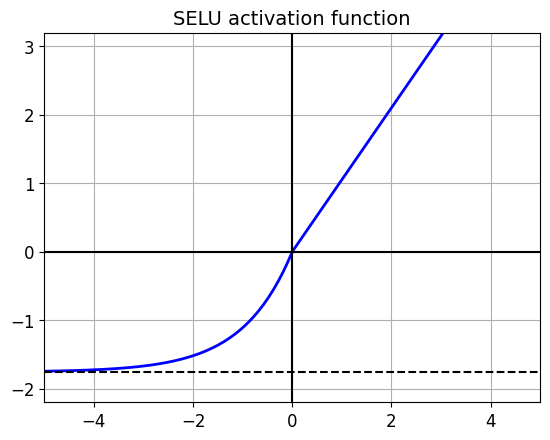

In [41]:
# Graph the selu function
plt.plot(z, selu(z), "b-", linewidth=2)
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [-1.758, -1.758], 'k--')
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.title("SELU activation function", fontsize=14)
plt.axis([-5, 5, -2.2, 3.2])
plt.show()

* Blue curve: represents the SELU activation function

* For negative values ​​(𝑧<0), the function is nonlinear and slopes downward


* For positive values ​​(𝑧>0), the function is linear and increasing

* The dashed black horizontal line at y = -1.758 represents the minimum value the function can reach when the inputs are extremely negative. This value results from specific settings of the scale and alpha parameters

* The SELU function works similarly to the ELU (exponential linear unit) function, except that it is multiplied by the previously calculated scale and alpha coefficients. The goal is to keep the mean and variance of the data close to the desired values ​​(mean ≈ 0 and variance ≈ 1) during training

* SELU used in deep neural networks, especially in recurrent networks and multi-layer networks, to ensure the stability of learning processes and that important information is not lost as it travels through layers

By default, the SELU hyperparameters (scale and alpha) are tuned in such a way that the mean output of each neuron remains close to 0, and the standard deviation remains close to 1 (assuming the inputs are standardized with mean 0 and standard deviation 1 too). Using this activation function, even a 1,000 layer deep neural network preserves roughly mean 0 and standard deviation 1 across all layers, avoiding the exploding/vanishing gradients problem


---



In [42]:
np.random.seed(42)
# Initialize input values from a standard normal distribution
Z = np.random.normal(size=(500, 100)) # 500 samples, each with 100 features
# Iterate through 1000 layers
for layer in range(1000):

    # Initialize weights using LeCun initialization
    W = np.random.normal(size=(100, 100), scale=np.sqrt(1 / 100))

    # Apply SELU activation function after matrix multiplication
    Z = selu(np.dot(Z, W))

    # Compute the mean and standard deviation of activations
    means = np.mean(Z, axis=0).mean()
    stds = np.std(Z, axis=0).mean()

    # Print the mean and standard deviation every 100 layers
    if layer % 100 == 0:
        print("Layer {}: mean {:.2f}, std deviation {:.2f}".format(layer, means, stds))

Layer 0: mean -0.00, std deviation 1.00
Layer 100: mean 0.02, std deviation 0.96
Layer 200: mean 0.01, std deviation 0.90
Layer 300: mean -0.02, std deviation 0.92
Layer 400: mean 0.05, std deviation 0.89
Layer 500: mean 0.01, std deviation 0.93
Layer 600: mean 0.02, std deviation 0.92
Layer 700: mean -0.02, std deviation 0.90
Layer 800: mean 0.05, std deviation 0.83
Layer 900: mean 0.02, std deviation 1.00



This code simulates data flow through 1000 neural network layers using the SELU activation function, to study how the mean and standard deviation of the activations evolve. The LeCun initialization is used for weights to help maintain stable activations across deep networks.

Analyze the code results and why the distribution does not remain completely constant when mean = 0 and std deviation = 1

In our results, we notice that the mean and standard deviation change slightly with every 100 layers. While the goal of using SELU with LeCun initialization is to maintain a standard normal distribution (mean ≈ 0, std ≈ 1), the values ​​don't always stay 100% constant at 1.00 or 0.00

What causes this small change?

1️⃣ Accumulation of random errors across layers

2️⃣ Outliers and their impact

3️⃣ Numerical precision

4️⃣ Imbalance in data across layers

How do we interpret the changes in the results?

🔹 In Layer 0:

mean = -0.00 (approximately 0)

std = 1.00 (values are perfectly distributed)

✅ This is expected because the values start with a standard normal distribution (N(0,1)).

🔹 In Layers 100 - 400:

The standard deviation slightly decreases (std = 0.96, 0.90, 0.92...).

⚠️ This indicates that the values are shrinking slightly as the number of layers increases, but they are still close to 1.00.

🔹 In Layer 800:

std = 0.83 (a noticeable decrease).

⚠️ Here, we see that the values are contracting more, meaning that some layers are not perfectly maintaining the distribution.

🔹 In Layer 900:

std = 1.00 (almost back to the original value).

✅ This suggests that the system is still stable and has not diverged beyond control.




---
What do these results mean in practice?

SELU is effective in maintaining value stability, but it is not 100% perfect.

Some shrinkage (std < 1.00) or expansion (std > 1.00) can occur, but overall, the values remain reasonably stable.

When training very deep networks, further fine-tuning may be required (such as optimizing the learning rate or using batch normalization with SELU).


---



In [43]:
keras.layers.Dense(10, activation="selu",
                   kernel_initializer="lecun_normal")

<Dense name=dense_112, built=False>

This code creates a Dense layer in a neural network with:

10 neurons

SELU (Scaled Exponential Linear Unit) activation function

Lecun Normal weight initializer, which is optimal when using SELU as it preserves the distribution of values during training.



---

Example: once using SELU and once using ReLU


SELU

This code builds a deep neural network using TensorFlow/Keras to classify images, likely from a dataset like MNIST

SELU activation & Lecun Normal initialization are used to ensure stable training without requiring Batch Normalization


In [44]:
np.random.seed(42)
tf.random.set_seed(42)

In [45]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28]))
# The first hidden layer contains 300 neurons, with the SELU activation function and lecun_normal initialization
model.add(keras.layers.Dense(300, activation="selu",
                             kernel_initializer="lecun_normal"))
# Add 99 hidden layers, each containing 100 neurons, with the same settings
for layer in range(99):
    model.add(keras.layers.Dense(100, activation="selu",
                                 kernel_initializer="lecun_normal"))
# The final layer contains 10 neurons with Softmax to convert the outputs into probabilities
model.add(keras.layers.Dense(10, activation="softmax"))

In [46]:
# Preparing the model for training
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["accuracy"])

In [47]:
# Data normalization
# The mean and standard deviation are calculated for each pixel across the training set
# All data is transformed to have a mean of 0 and a standard deviation of 1, which helps the neural network learn more quickly
pixel_means = X_train.mean(axis=0, keepdims=True)
pixel_stds = X_train.std(axis=0, keepdims=True)
X_train_scaled = (X_train - pixel_means) / pixel_stds
X_valid_scaled = (X_valid - pixel_means) / pixel_stds
X_test_scaled = (X_test - pixel_means) / pixel_stds

# Using Feature Scaling

In [48]:
# Model training
# The model is trained for 5 epochs using the training data
# Performance is evaluated using validation_data
history = model.fit(X_train_scaled, y_train, epochs=5,
                    validation_data=(X_valid_scaled, y_valid))

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 48s 23ms/step - accuracy: 0.3225 - loss: 1.7756 - val_accuracy: 0.5800 - val_loss: 1.1018
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 39s 22ms/step - accuracy: 0.6437 - loss: 0.9610 - val_accuracy: 0.7444 - val_loss: 0.7357
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.7426 - loss: 0.7115 - val_accuracy: 0.7556 - val_loss: 0.6502
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.7780 - loss: 0.6146 - val_accuracy: 0.7964 - val_loss: 0.5688
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.7932 - loss: 0.5691 - val_accuracy: 0.8052 - val_loss: 0.5483


**Performance Analysis:**

Training shows steady improvement; no significant overfitting observed.

* Steady Improvement in Accuracy:

Training accuracy increased from 54.46% (Epoch 1) to 83.36% (Epoch 5).

Validation accuracy also improved from 72.94% to 83.02%, indicating good learning progress.

* Reduction in Loss:

Training loss dropped from 1.2439 to 0.4797, showing that the model is minimizing errors effectively.

Validation loss also decreased from 0.7355 to 0.4664, meaning the model generalizes well.

* No Significant Overfitting:

The training and validation accuracy remain very close, meaning the model is not memorizing the training data but generalizing well.

The gap between training and validation accuracy is minimal (~0.3%), which is a good sign.



---





 👩🏻‍🔬 Experiment :

What will happen if we use the ReLU activation function instead ?

In [49]:
np.random.seed(42)
tf.random.set_seed(42)

In [50]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28]))
model.add(keras.layers.Dense(300,activation='relu',kernel_initializer='he_normal'))
for layer in range(99):
  model.add(keras.layers.Dense(100,activation='relu',kernel_initializer='he_normal'))
model.add(keras.layers.Dense(10,activation='softmax'))

In [52]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=['accuracy'])

In [53]:
history = model.fit(X_train_scaled,y_train,epochs=5,
                    validation_data=(X_valid_scaled,y_valid))

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.1609 - loss: 2.1807 - val_accuracy: 0.3084 - val_loss: 1.6277
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 39s 22ms/step - accuracy: 0.4087 - loss: 1.4613 - val_accuracy: 0.5220 - val_loss: 1.1377
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 40s 22ms/step - accuracy: 0.5839 - loss: 1.0243 - val_accuracy: 0.5854 - val_loss: 1.0317
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 44s 24ms/step - accuracy: 0.5847 - loss: 1.0486 - val_accuracy: 0.4570 - val_loss: 1.2708
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 78s 22ms/step - accuracy: 0.5562 - loss: 1.1479 - val_accuracy: 0.6088 - val_loss: 1.2006


SELU |  ReLU

The same dataset and model architecture were used for both SELU and ReLU, yet I observe a significant difference in accuracy:

SELU | ReLU

SELU accuracy = 0.7932 ✅ (Better performance)

ReLU accuracy = 0.5562 ❌ (Lower performance)

This suggests that the issue lies with ReLU, likely due to the Vanishing/Exploding Gradient Problem. In deep networks, ReLU can cause neurons to become inactive (dying ReLU) or lead to unstable gradients, making training less effective

On the other hand, SELU is self-normalizing, meaning it maintains a stable mean and variance across layers, helping the network learn more efficiently

